In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df=pd.read_csv('Data/atp_tennis.csv')

In [104]:
df.tail()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
68094,Eastbourne International,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Samuel T.,Bergs Z.,Bergs Z.,142,48,414,1010,2.38,1.57,6-4 6-7 2-6
68095,Mallorca Championships,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Marozsan F.,Davidovich Fokina A.,Davidovich Fokina A.,62,25,895,1910,3.00,1.40,7-5 2-6 4-6
68096,Mallorca Championships,2026-06-26,ATP250,Outdoor,Grass,Semifinals,3,Quinn E.,Borges N.,Quinn E.,63,53,894,945,2.20,1.67,6-1 6-2
68097,Mallorca Championships,2026-06-27,ATP250,Outdoor,Grass,The Final,3,Davidovich Fokina A.,Quinn E.,Davidovich Fokina A.,25,63,1910,894,1.57,2.38,7-6 6-3
68098,Eastbourne International,2026-06-28,ATP250,Outdoor,Grass,The Final,3,Humbert U.,Bergs Z.,Bergs Z.,30,48,1510,1010,1.36,3.20,6-3 1-6 4-6


In [55]:
from collections import defaultdict

# Stores wins for each unordered player pair
h2h = defaultdict(lambda: {0: 0, 1: 0})

h2h_win_pct = []
player1_higher_h2h = []

for _, row in df.iterrows():

    p1 = row["Player_1"]
    p2 = row["Player_2"]
    winner = row["Winner"]

    # Order-independent key
    key = tuple(sorted([p1, p2]))

    if key[0] == p1:
        idx1, idx2 = 0, 1
    else:
        idx1, idx2 = 1, 0

    p1_wins = h2h[key][idx1]
    p2_wins = h2h[key][idx2]

    total = p1_wins + p2_wins

    # Win percentage for Player_1
    if total == 0:
        h2h_win_pct.append(0.5)
    else:
        h2h_win_pct.append(p1_wins / total)

    # Higher H2H record (ties count as 0.5)
    if p1_wins > p2_wins:
        player1_higher_h2h.append(1)
    elif p1_wins < p2_wins:
        player1_higher_h2h.append(0)
    else:
        player1_higher_h2h.append(0.5)

    # Update AFTER creating features
    if winner == p1:
        h2h[key][idx1] += 1
    else:
        h2h[key][idx2] += 1

df["Player1_H2H_WinPct"] = h2h_win_pct
df["Higher_H2H_Player"] = player1_higher_h2h

In [56]:
from collections import defaultdict, deque

# Stores last 5 match results for each player
history = defaultdict(lambda: deque(maxlen=5))

recent_win_pct_1 = []
recent_win_pct_2 = []

for _, row in df.iterrows():

    p1 = row["Player_1"]
    p2 = row["Player_2"]
    winner = row["Winner"]

    # Player 1 recent form BEFORE this match
    if len(history[p1]) == 0:
        recent_win_pct_1.append(0.5)
    else:
        recent_win_pct_1.append(sum(history[p1]) / len(history[p1]))

    # Player 2 recent form BEFORE this match
    if len(history[p2]) == 0:
        recent_win_pct_2.append(0.5)
    else:
        recent_win_pct_2.append(sum(history[p2]) / len(history[p2]))

    # Update histories AFTER computing the feature
    if winner == p1:
        history[p1].append(1)
        history[p2].append(0)
    else:
        history[p1].append(0)
        history[p2].append(1)

df["RecentWinPct_1"] = recent_win_pct_1
df["RecentWinPct_2"] = recent_win_pct_2

In [57]:
df.drop(columns=["Tournament","Series","Pts_1","Pts_2","Odd_1","Odd_2","Score"],inplace=True)
df.head(5)

,Date,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2
0,2000-01-03,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5
1,2000-01-03,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5
2,2000-01-03,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5
3,2000-01-03,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5
4,2000-01-03,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5


In [58]:
df.iloc[5677]

Date                  2001-10-22
Court                     Indoor
Surface                   Carpet
Round                  1st Round
Best of                        3
Player_1                 Huet S.
Player_2              Roddick A.
Winner                Roddick A.
Rank_1                       269
Rank_2                        16
Player1_H2H_WinPct           0.5
Higher_H2H_Player            0.5
RecentWinPct_1               0.2
RecentWinPct_2               0.6
Name: 5677, dtype: object

In [59]:
df['Month']=df['Date'].str.split('-').str[1]

In [60]:
df.head()

,Date,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Month
0,2000-01-03,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5,01
1,2000-01-03,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5,01
2,2000-01-03,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5,01
3,2000-01-03,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5,01
4,2000-01-03,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5,01


In [61]:
df['Season']=df['Month'].apply(lambda x: 'Winter' if x in ['12','01','02'] else ('Spring' if x in ['03','04','05'] else ('Summer' if x in ['06','07','08'] else 'Autumn'))) 

In [62]:
df.head()

,Date,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Month,Season
0,2000-01-03,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5,01,Winter
1,2000-01-03,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5,01,Winter
2,2000-01-03,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5,01,Winter
3,2000-01-03,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5,01,Winter
4,2000-01-03,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5,01,Winter


In [63]:
df.drop(columns=["Date","Month"],inplace=True)
df.head()

,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season
0,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5,Winter
1,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5,Winter
2,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5,Winter
3,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5,Winter
4,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5,Winter


In [64]:
df['Court'].value_counts()

Court
Outdoor    56078
Indoor     12021
Name: count, dtype: int64

In [65]:
df['Surface'].value_counts()

Surface
Hard      36836
Clay      22020
Grass      7611
Carpet     1632
Name: count, dtype: int64

In [66]:
df.isna().sum()

Court                 0
Surface               0
Round                 0
Best of               0
Player_1              0
Player_2              0
Winner                0
Rank_1                0
Rank_2                0
Player1_H2H_WinPct    0
Higher_H2H_Player     0
RecentWinPct_1        0
RecentWinPct_2        0
Season                0
dtype: int64

In [67]:
df['Round'].value_counts()

Round
1st Round        31171
2nd Round        19008
Quarterfinals     6443
3rd Round         4813
Semifinals        3294
The Final         1673
4th Round         1271
Round Robin        426
Name: count, dtype: int64

In [68]:
df.shape

(68099, 14)

In [69]:
df['Player_1'].value_counts()

Player_1
Federer R.       668
Nadal R.         619
Djokovic N.      612
Ferrer D.        539
Gasquet R.       483
                ... 
Rottgering M.      1
Gentzsch T.        1
Wendelken H.       1
Ghibaudo A.        1
Stewart H.         1
Name: count, Length: 1547, dtype: int64

In [70]:
df['Player_2'].value_counts()

Player_2
Federer R.       725
Djokovic N.      660
Nadal R.         595
Ferrer D.        496
Verdasco F.      488
                ... 
Boogaard T.        1
Schoenhaus M.      1
Gill F.            1
Cassone M.         1
Samuel T.          1
Name: count, Length: 1523, dtype: int64

In [71]:
df.head()

,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season
0,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5,Winter
1,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5,Winter
2,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5,Winter
3,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5,Winter
4,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5,Winter


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68099 entries, 0 to 68098
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Court               68099 non-null  str    
 1   Surface             68099 non-null  str    
 2   Round               68099 non-null  str    
 3   Best of             68099 non-null  int64  
 4   Player_1            68099 non-null  str    
 5   Player_2            68099 non-null  str    
 6   Winner              68099 non-null  str    
 7   Rank_1              68099 non-null  int64  
 8   Rank_2              68099 non-null  int64  
 9   Player1_H2H_WinPct  68099 non-null  float64
 10  Higher_H2H_Player   68099 non-null  float64
 11  RecentWinPct_1      68099 non-null  float64
 12  RecentWinPct_2      68099 non-null  float64
 13  Season              68099 non-null  str    
dtypes: float64(4), int64(3), str(7)
memory usage: 7.3 MB


In [73]:
df.isnull().sum()

Court                 0
Surface               0
Round                 0
Best of               0
Player_1              0
Player_2              0
Winner                0
Rank_1                0
Rank_2                0
Player1_H2H_WinPct    0
Higher_H2H_Player     0
RecentWinPct_1        0
RecentWinPct_2        0
Season                0
dtype: int64

In [74]:
df.shape

(68099, 14)

In [75]:
print(df.duplicated().sum())

0


In [76]:
df = df.drop_duplicates()

In [77]:
df.shape

(68099, 14)

In [78]:
df.head()

,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season
0,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5,Winter
1,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5,Winter
2,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5,Winter
3,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5,Winter
4,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5,Winter


In [79]:
# Dictionaries to store historical stats
wins = {}
matches = {}

surface_pct_1 = []
surface_pct_2 = []

for _, row in df.iterrows():

    p1 = row["Player_1"]
    p2 = row["Player_2"]
    surface = row["Surface"]
    winner = row["Winner"]

    key1 = (p1, surface)
    key2 = (p2, surface)

    # Player 1 percentage BEFORE this match
    w1 = wins.get(key1, 0)
    m1 = matches.get(key1, 0)
    surface_pct_1.append(w1 / m1 if m1 else 0.5)

    # Player 2 percentage BEFORE this match
    w2 = wins.get(key2, 0)
    m2 = matches.get(key2, 0)
    surface_pct_2.append(w2 / m2 if m2 else 0.5)

    # Update match counts
    matches[key1] = m1 + 1
    matches[key2] = m2 + 1

    # Update winner
    if winner == p1:
        wins[key1] = w1 + 1
    else:
        wins[key2] = w2 + 1

df["Surface_WinPct_1"] = surface_pct_1
df["Surface_WinPct_2"] = surface_pct_2

In [80]:
df.head()

,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2
0,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5,Winter,0.5,0.5
1,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5,Winter,0.5,0.5
2,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5,Winter,0.5,0.5
3,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5,Winter,0.5,0.5
4,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5,Winter,0.5,0.5


In [81]:
df["Winner_Encoded"] = np.where(df["Winner"] == df["Player_1"], 1, 0)

In [82]:
df.head()

,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2,Winner_Encoded
0,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
1,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
2,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
3,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,0.5,0.5,0.5,0.5,Winter,0.5,0.5,1
4,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0


In [83]:
df.drop(columns=['Player_1','Player_2','Winner'],inplace=True)
df.head()

,Court,Surface,Round,Best of,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2,Winner_Encoded
0,Outdoor,Hard,1st Round,3,105,58,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
1,Outdoor,Hard,1st Round,3,218,11,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
2,Outdoor,Hard,1st Round,3,56,5,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
3,Outdoor,Hard,1st Round,3,63,77,0.5,0.5,0.5,0.5,Winter,0.5,0.5,1
4,Outdoor,Hard,1st Round,3,155,15,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0


In [84]:
df.shape

(68099, 14)

In [85]:
df=df[df['Round']!="Round Robin"]

In [86]:
df.shape

(67673, 14)

In [87]:
df['Round'].value_counts()

Round
1st Round        31171
2nd Round        19008
Quarterfinals     6443
3rd Round         4813
Semifinals        3294
The Final         1673
4th Round         1271
Name: count, dtype: int64

In [88]:
df['Surface'].value_counts()

Surface
Hard      36457
Clay      21973
Grass      7611
Carpet     1632
Name: count, dtype: int64

In [89]:
df.head()

,Court,Surface,Round,Best of,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2,Winner_Encoded
0,Outdoor,Hard,1st Round,3,105,58,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
1,Outdoor,Hard,1st Round,3,218,11,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
2,Outdoor,Hard,1st Round,3,56,5,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0
3,Outdoor,Hard,1st Round,3,63,77,0.5,0.5,0.5,0.5,Winter,0.5,0.5,1
4,Outdoor,Hard,1st Round,3,155,15,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0


In [90]:
df['Court']=df['Court'].astype('object')
df['Surface']=df['Surface'].astype('object')
df['Round']=df['Round'].astype('object')
df['Season']=df['Season'].astype('object')

In [91]:
df["Higher_Rank_Player"] = np.where(
    df["Rank_1"] < df["Rank_2"],1,0
)

In [92]:
df.head()

,Court,Surface,Round,Best of,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2,Winner_Encoded,Higher_Rank_Player
0,Outdoor,Hard,1st Round,3,105,58,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0
1,Outdoor,Hard,1st Round,3,218,11,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0
2,Outdoor,Hard,1st Round,3,56,5,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0
3,Outdoor,Hard,1st Round,3,63,77,0.5,0.5,0.5,0.5,Winter,0.5,0.5,1,1
4,Outdoor,Hard,1st Round,3,155,15,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0


In [93]:
df["Abs_Rank_Diff"] = (df["Rank_1"] - df["Rank_2"]).abs()

In [94]:
df.head()

,Court,Surface,Round,Best of,Rank_1,Rank_2,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2,Winner_Encoded,Higher_Rank_Player,Abs_Rank_Diff
0,Outdoor,Hard,1st Round,3,105,58,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,47
1,Outdoor,Hard,1st Round,3,218,11,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,207
2,Outdoor,Hard,1st Round,3,56,5,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,51
3,Outdoor,Hard,1st Round,3,63,77,0.5,0.5,0.5,0.5,Winter,0.5,0.5,1,1,14
4,Outdoor,Hard,1st Round,3,155,15,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,140


In [95]:
df.drop(columns=['Rank_1','Rank_2'],inplace=True)

In [96]:
df.head()

,Court,Surface,Round,Best of,Player1_H2H_WinPct,Higher_H2H_Player,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2,Winner_Encoded,Higher_Rank_Player,Abs_Rank_Diff
0,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,47
1,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,207
2,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,51
3,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,0.5,Winter,0.5,0.5,1,1,14
4,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,0.5,Winter,0.5,0.5,0,0,140


<Axes: >

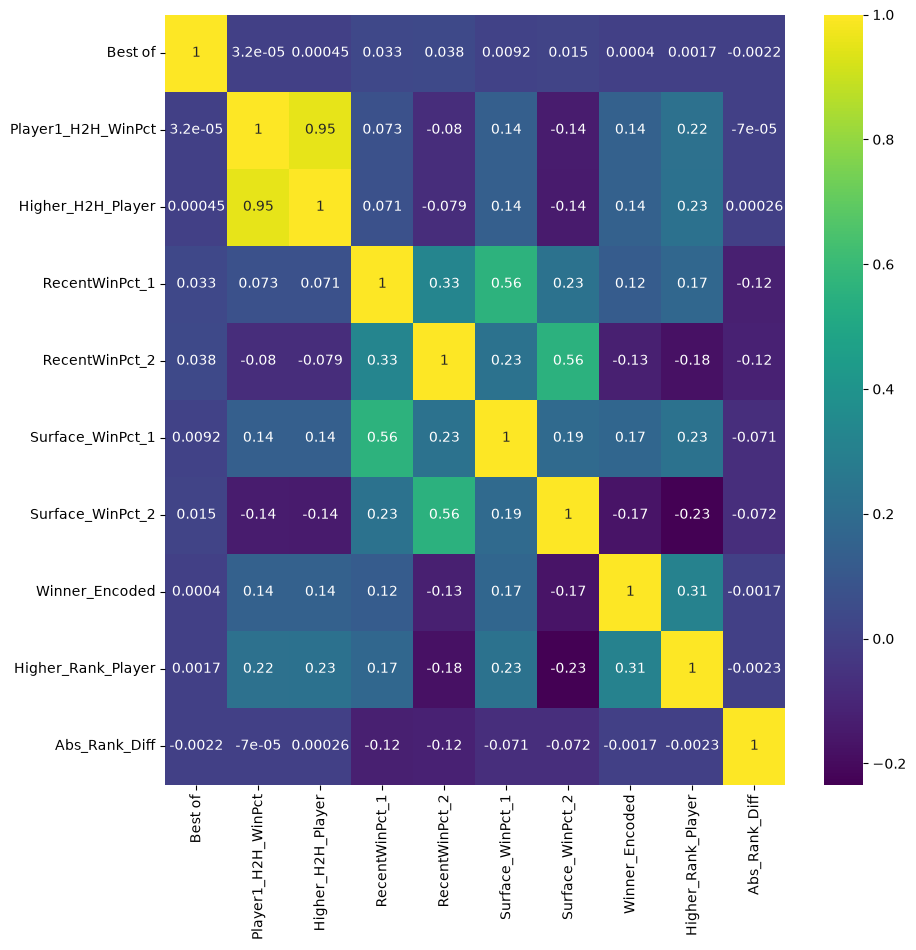

In [97]:
plt.figure(figsize=(10,10))
sns.heatmap(data=df.corr(numeric_only=True),cmap='viridis',annot=True)

In [98]:
df=df.drop(columns=['Higher_H2H_Player'])

In [99]:
df.head()

,Court,Surface,Round,Best of,Player1_H2H_WinPct,RecentWinPct_1,RecentWinPct_2,Season,Surface_WinPct_1,Surface_WinPct_2,Winner_Encoded,Higher_Rank_Player,Abs_Rank_Diff
0,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,Winter,0.5,0.5,0,0,47
1,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,Winter,0.5,0.5,0,0,207
2,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,Winter,0.5,0.5,0,0,51
3,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,Winter,0.5,0.5,1,1,14
4,Outdoor,Hard,1st Round,3,0.5,0.5,0.5,Winter,0.5,0.5,0,0,140


In [ ]:
df.isna().sum()

In [101]:
df.to_csv("Data/Tennis_Usable.csv",index=False)